# 完整的模型训练套路
- 利用GPU训练（这里用方法1，方法2更常用，见笔记文档）

In [15]:
import torchvision
import torch
from torch.utils.data import DataLoader
from torch import nn
from torch.utils.tensorboard import SummaryWriter

In [16]:
torch.cuda.is_available()

True

In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 用GPU的方法2（更常用）

## 1. 准备数据集

- 数据集以 CIFAR10 数据集为例

In [17]:
train_data = torchvision.datasets.CIFAR10(root="my_cifar10", train=True, transform=torchvision.transforms.ToTensor(), download=True)
test_data = torchvision.datasets.CIFAR10(root="my_cifar10", train=False, transform=torchvision.transforms.ToTensor(), download=True)

In [18]:
print("训练集长度为{}".format(len(train_data))) # 注意格式化字符串的用法

训练集长度为50000


In [19]:
print("测试集长度为{}".format(len(test_data)))

测试集长度为10000


## 2. 用DataLoader加载数据集

In [20]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

## 3. 搭建神经网络

- 搭建这个↓ \
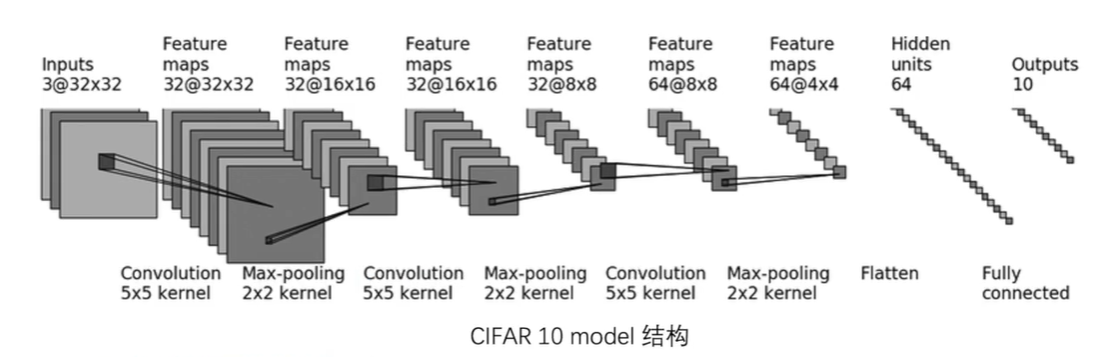

In [21]:
class model(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2, stride=1),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 32, kernel_size=5, padding=2, stride=1),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2, stride=1),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64*4*4, 64),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        output = self.seq(x)
        return output

## 4. 检查神经网络

- 实例化模型

In [22]:
my_model = model()

In [40]:
if torch.cuda.is_available():
    my_model = my_model.cuda() # 用GPU训练

- 测试参数

In [23]:
input_test = torch.ones(size=(64, 3, 32, 32))
output_test = my_model(input_test)
output_test.shape

torch.Size([64, 10])

## 5. 设置损失函数、优化器

- 损失函数

In [24]:
loss_fn = nn.CrossEntropyLoss() # 交叉熵损失函数

In [41]:
if torch.cuda.is_available():
    loss_fn = loss_fn.cuda() # 用GPU训练

- 优化器

In [25]:
learning_rate = 0.01 # 或者：1e-2
optimizer = torch.optim.SGD(my_model.parameters(), lr=learning_rate) # 随机梯度下降优化

## 6. 设置一些参数

- 记录训练 / 测试次数

In [26]:
total_train_step = 0
total_test_step = 0

- 训练轮数

In [38]:
epoch = 5

## 7. 训练、测试

- 写入日志（Tensorboard），**画损失函数图**

In [28]:
writer = SummaryWriter("logs_model")

- 训练、验证

In [39]:
total_train_step = 0

for i in range(epoch):
    print("----------------第{}轮训练开始----------------".format(i+1))

    # 训练：
    my_model.train() # 可以不写，一般都写，让非训练层不发挥作用

    for data in train_dataloader:     
        # 训练得到输出
        imgs, targets = data

        if torch.cuda.is_available():
            imgs = imgs.cuda() # 用GPU训练
            targets = targets.cuda() # 用GPU训练

        outputs = my_model(imgs)

        # 得到损失函数
        loss = loss_fn(outputs, targets)

        #优化器优化模型参数
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_step += 1 # 记录训练次数
        if total_train_step % 100 == 0: # 每一百次训练输出一次loss
            print("训练次数：{}, Loss:{}".format(total_train_step, loss.item())) # loss.item()表示只输出数字，不输出类型
            writer.add_scalar("train_loss", loss.item(), global_step=total_train_step) # 写入日志，画损失函数图

    # 测试（验证）：
    my_model.eval() # 可以不写，一般都写，让非测试层不发挥作用

    total_test_loss = 0.0
    total_accu = 0.0

    with torch.no_grad():
        for data in test_dataloader:
            imgs, targets = data

            if torch.cuda.is_available():
                imgs = imgs.cuda() # 用GPU训练
                targets = targets.cuda() # 用GPU训练
                
            outputs = my_model(imgs)
            loss = loss_fn(outputs, targets)
            total_test_loss += loss.item() # 得到整个测试集上的loss
            accuracy = (outputs.argmax(1) == targets).sum()
            total_accu += accuracy

    print()
    print("第{}轮训练结果，整个测试集上的Loss为:{}".format(i+1, total_test_loss))
    print("第{}轮测试集上的正确率为:{}".format(i+1, total_accu/len(test_data)))

    writer.add_scalar("test_loss", total_test_loss, global_step=total_test_step) # 写入日志，画损失函数图
    writer.add_scalar("test_accuracy", total_accu/len(test_data), global_step=total_test_step) # 写入日志，画准确率变化图

    total_test_step += 1

    torch.save(my_model, "my_model_{}.pth".format(i)) # 保存每一轮训练的模型，注意参数格式
    # torch.save(my_model.state_dict(), "my_model_dict_{}.pth".format(i)) # 更推荐这种方式保存
    print("模型已保存")
    print()

writer.close()

----------------第1轮训练开始----------------
训练次数：100, Loss:1.2308086156845093
训练次数：200, Loss:1.0788252353668213
训练次数：300, Loss:1.1273140907287598
训练次数：400, Loss:1.6453930139541626
训练次数：500, Loss:1.5727744102478027
训练次数：600, Loss:1.1613105535507202
训练次数：700, Loss:1.200618028640747

第1轮训练结果，整个测试集上的Loss为:208.4713574051857
第1轮测试集上的正确率为:0.5289999842643738
模型已保存

----------------第2轮训练开始----------------
训练次数：800, Loss:1.1907051801681519
训练次数：900, Loss:1.3191897869110107
训练次数：1000, Loss:1.1225929260253906
训练次数：1100, Loss:1.009066104888916
训练次数：1200, Loss:1.3412773609161377
训练次数：1300, Loss:0.8840641975402832
训练次数：1400, Loss:0.89862060546875
训练次数：1500, Loss:1.1316877603530884

第2轮训练结果，整个测试集上的Loss为:192.03406924009323
第2轮测试集上的正确率为:0.5724999904632568
模型已保存

----------------第3轮训练开始----------------
训练次数：1600, Loss:1.1063916683197021
训练次数：1700, Loss:1.0658226013183594
训练次数：1800, Loss:1.027633786201477
训练次数：1900, Loss:1.1901246309280396
训练次数：2000, Loss:1.0044423341751099
训练次数：2100, Loss:1.1617786884307861


*用了GPU明显快很多*

## 8. 准确率评估

- 测试演示

In [ ]:
# 演示
test = torch.tensor([[0.1, 0.2],
                    [0.05, 0.3]])
print(test.argmax(1)) # 1表示按列，输出每行最大的列索引

tensor([1, 1])


In [ ]:
pred = test.argmax(1)
target = torch.tensor([0, 1])
print(pred == target)

tensor([False,  True])


In [ ]:
print("准确率：", (sum(pred == target)/len(target)).item()) # 输出准确率

准确率： 0.5
